#### imports

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score,recall_score, confusion_matrix 

import pickle


In [15]:
import warnings
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

#### load data

In [2]:
data = pd.read_csv(r'C:\Users\psxea2\Desktop\Amdaritelecomchurn\reder-prediction\EDA\clean_data.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12483 entries, 0 to 12482
Columns: 104 entries, Gender_Female to LastEmailClickedDate_Day
dtypes: float64(41), int64(63)
memory usage: 9.9 MB


In [4]:
data.columns

Index(['Gender_Female', 'Gender_Male', 'Frequency_Daily', 'Frequency_Monthly',
       'Frequency_Weekly', 'FirstActionType_Add to Cart',
       'FirstActionType_Click', 'FirstActionType_Search',
       'TotalInteractionType_Call', 'TotalInteractionType_Call,Chat',
       ...
       'most_recent_action_date_Day', 'LastEmailSentDate_Year',
       'LastEmailSentDate_Month', 'LastEmailSentDate_Day',
       'LastEmailOpenedDate_Year', 'LastEmailOpenedDate_Month',
       'LastEmailOpenedDate_Day', 'LastEmailClickedDate_Year',
       'LastEmailClickedDate_Month', 'LastEmailClickedDate_Day'],
      dtype='object', length=104)

In [5]:
x = data.drop(columns=['ChurnLabel'])
y = data[['ChurnLabel']]

In [6]:
xcols=x.columns.to_list()

In [7]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
standard_df = sc.fit_transform(x)
standard_df = pd.DataFrame(standard_df, columns =xcols)

In [12]:
x=standard_df.copy()

#### split data into train and test set

In [ ]:
# split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### Training a base model

In [16]:
#fit
model = LogisticRegression()
model.fit(x_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:

#predict
y_pred = model.predict(x_test)


In [18]:
score = accuracy_score(y_pred, y_test)
print('Accuracy_score:', round(score*100, 2))
print('precision_score:', round(precision_score(y_pred,y_test)*100, 2)),
print('recall_score:', round(recall_score(y_pred,y_test)*100,2))

#precision score before scaling:81.94, recall score:63.37

#accuracy score before scaling:67.64

Accuracy_score: 96.6
precision_score: 96.03
recall_score: 97.05


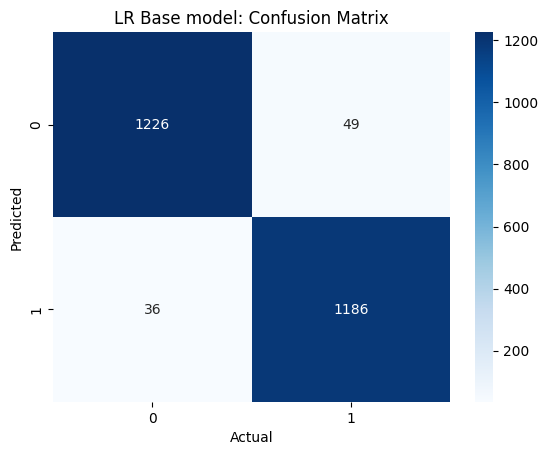

In [19]:
cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d')
plt.title('LR Base model: Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()



##### Hyperparameter tuning : Logistic Regression

{'solver': 'sag', 'penalty': 'l2', 'max_iter': 200}
Accuracy: 96.6
Precision: 97.05
Recall: 96.03


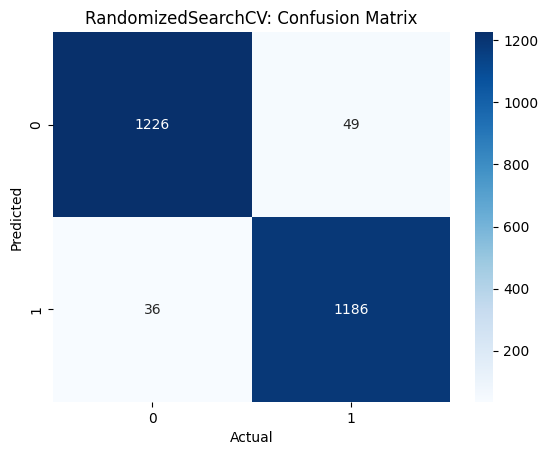

In [22]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

param_dist = {
'penalty': ['l1','l2','elastic_net'],
'solver':['saga','sag','newton-chelsky'],
'max_iter':[100, 200, 300]
}

model = LogisticRegression(random_state=42, n_jobs=1)
random_search = RandomizedSearchCV(model, param_distributions=param_dist, cv=4, random_state=42)

random_search.fit(x_train,y_train)
best_param = random_search.best_params_
best_model = random_search.best_estimator_

print(best_param)

y_pred = best_model.predict(x_test)

a_score = accuracy_score(y_test, y_pred)
p_score = precision_score(y_test, y_pred)
r_score = recall_score(y_test, y_pred)



print('Accuracy:', round(accuracy_score(y_test,y_pred)*100,2))
print('Precision:', round(precision_score(y_test,y_pred)*100,2))
print('Recall:', round(recall_score(y_test,y_pred)*100,2))


cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d')
plt.title('RandomizedSearchCV: Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()



{'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Accuracy: 96.6
Precision: 97.05
Recall: 96.03


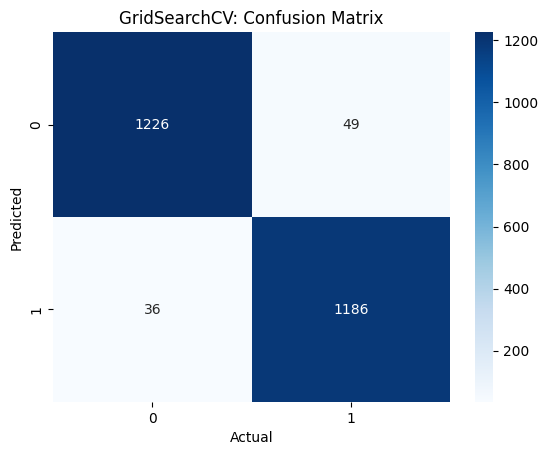

In [23]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

param_dist = {
'penalty': ['l1','l2','elastic_net'],
'solver':['saga','sag','newton-chelsky'],
'max_iter':[100, 200, 300]
}

model = LogisticRegression(random_state=42, n_jobs=1)
grd_search = GridSearchCV(model, param_grid=param_dist, cv=4)

grd_search.fit(x_train,y_train)
best_param = grd_search.best_params_
best_model = grd_search.best_estimator_

print(best_param)

y_pred = best_model.predict(x_test)

acc_score = accuracy_score(y_test, y_pred)
prec_score = precision_score(y_test, y_pred)
rec_score = recall_score(y_test, y_pred)



print('Accuracy:', round(acc_score*100,2))
print('Precision:', round(prec_score*100,2))
print('Recall:', round(rec_score*100,2))

cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d')
plt.title('GridSearchCV: Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()



##### random forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)

Accuracy: 97.20%
Precision: 97.09%
Recall: 97.25%


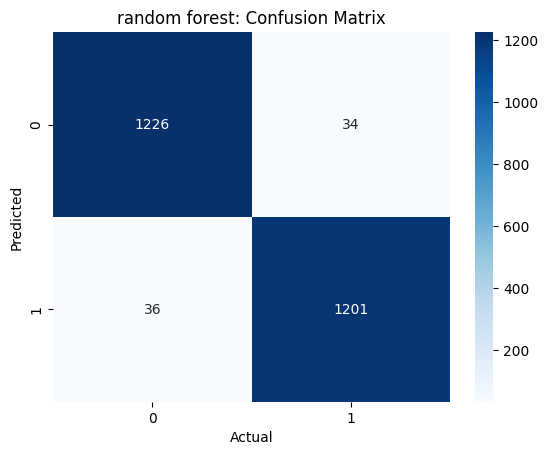

In [25]:
print(f'Accuracy: {accuracy_score(y_test,y_pred)*100:.2f}%')
print(f'Precision: {precision_score(y_test,y_pred)*100:.2f}%')
print(f'Recall: {recall_score(y_test,y_pred)*100:.2f}%')

cm = confusion_matrix(y_pred, y_test)
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d')
plt.title('random forest: Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
#scores before  scaling the data:  acc-97.24%, prec-97.09%, recall-97.33%